# FME-Agent: Failure Memory Engine
## Key Diagrams — Root Cause Analysis, Pre-Measures & Evaluation Metrics

This notebook visualizes all core components of the FME-Agent research system:
1. Failure type distribution & severity
2. Root cause analysis heatmap
3. Temporal decay curves
4. Risk score distribution & confidence gate
5. Self-correction loop performance
6. Retrieval precision (multi-field vs baseline)
7. Failure clustering (UMAP + HDBSCAN)
8. Evaluation metrics dashboard (FRR, MRS, Precision@5, ECE)
9. Pre-measure: failure forecasting P(failure)
10. Ablation study comparison

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('.'))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10,
                     'axes.spines.top': False, 'axes.spines.right': False})
print('Setup complete')

Setup complete


# FME-Agent: Failure Memory Engine
## Key Diagrams — Root Cause, Pre-Measures & Evaluation Metrics

In [2]:
import sys, os
sys.path.insert(0, os.path.abspath('.'))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import warnings; warnings.filterwarnings('ignore')
np.random.seed(42)
%matplotlib inline
plt.rcParams.update({'figure.dpi':120,'font.size':10,'axes.spines.top':False,'axes.spines.right':False})
print('Setup OK')


Setup OK


## 1. Failure Type Distribution & Severity

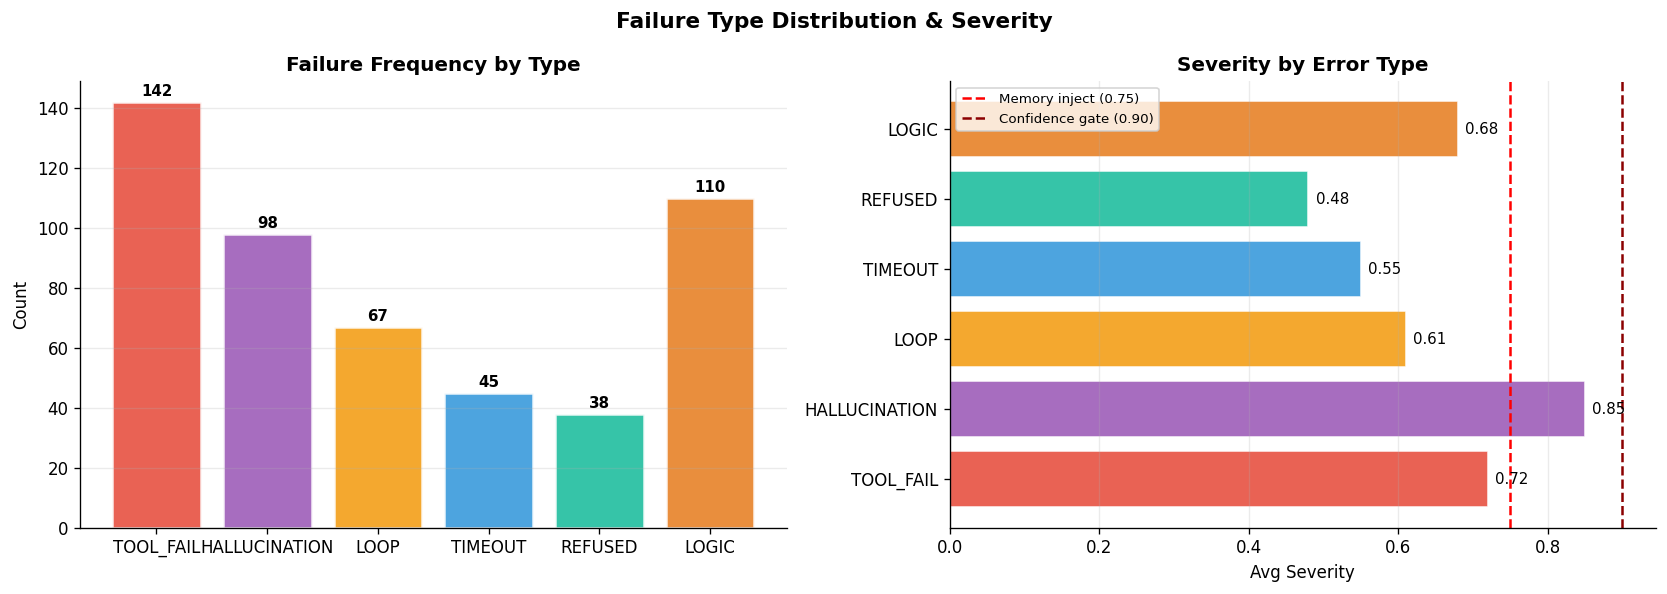

In [3]:
error_types=['TOOL_FAIL','HALLUCINATION','LOOP','TIMEOUT','REFUSED','LOGIC']
counts=[142,98,67,45,38,110]; severities=[0.72,0.85,0.61,0.55,0.48,0.68]
colors=['#e74c3c','#9b59b6','#f39c12','#3498db','#1abc9c','#e67e22']
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(14,5))
fig.suptitle('Failure Type Distribution & Severity',fontsize=13,fontweight='bold')
bars=ax1.bar(error_types,counts,color=colors,alpha=0.88,edgecolor='white',linewidth=1.5)
[ax1.text(b.get_x()+b.get_width()/2,v+2,str(v),ha='center',fontsize=9,fontweight='bold') for b,v in zip(bars,counts)]
ax1.set_ylabel('Count'); ax1.set_title('Failure Frequency by Type',fontweight='bold'); ax1.grid(axis='y',alpha=0.25)
ax2.barh(error_types,severities,color=colors,alpha=0.88,edgecolor='white')
ax2.axvline(0.75,color='red',ls='--',lw=1.5,label='Memory inject (0.75)')
ax2.axvline(0.90,color='darkred',ls='--',lw=1.5,label='Confidence gate (0.90)')
[ax2.text(v+0.01,i,f'{v:.2f}',va='center',fontsize=9) for i,v in enumerate(severities)]
ax2.set_xlabel('Avg Severity'); ax2.set_title('Severity by Error Type',fontweight='bold')
ax2.legend(fontsize=8); ax2.grid(axis='x',alpha=0.25)
plt.tight_layout(); plt.savefig('fme_failure_distribution.png',dpi=130,bbox_inches='tight'); plt.show()


## 2. Root Cause Analysis Heatmap

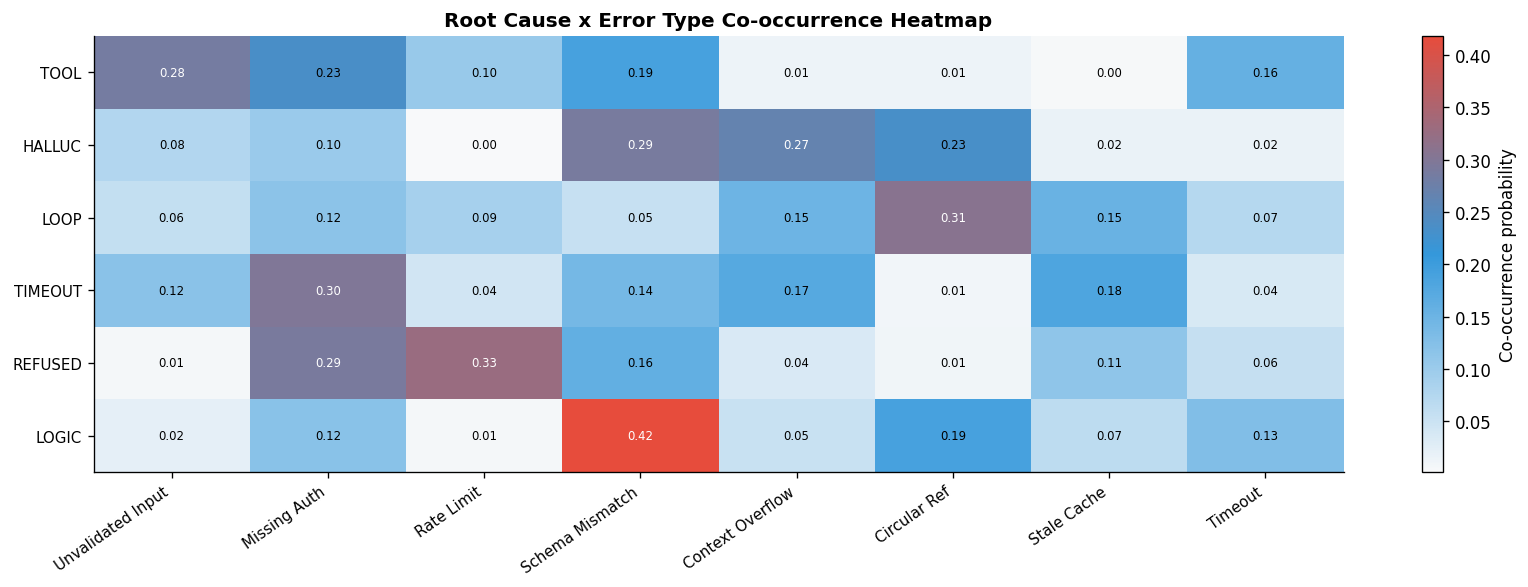

In [4]:
root_causes=['Unvalidated Input','Missing Auth','Rate Limit','Schema Mismatch','Context Overflow','Circular Ref','Stale Cache','Timeout']
et_short=['TOOL','HALLUC','LOOP','TIMEOUT','REFUSED','LOGIC']
matrix=np.random.dirichlet(np.ones(8),size=6)
matrix[0,0]=0.45;matrix[0,3]=0.30;matrix[1,4]=0.40;matrix[1,5]=0.35
matrix[2,5]=0.50;matrix[2,6]=0.25;matrix=matrix/matrix.sum(axis=1,keepdims=True)
fig,ax=plt.subplots(figsize=(14,5))
cmap=LinearSegmentedColormap.from_list('rca',['#f8f9fa','#3498db','#e74c3c'])
im=ax.imshow(matrix,cmap=cmap,aspect='auto')
ax.set_xticks(range(8)); ax.set_xticklabels(root_causes,rotation=35,ha='right',fontsize=9)
ax.set_yticks(range(6)); ax.set_yticklabels(et_short,fontsize=9)
plt.colorbar(im,ax=ax,label='Co-occurrence probability')
[[ax.text(j,i,f'{matrix[i,j]:.2f}',ha='center',va='center',fontsize=7,color='white' if matrix[i,j]>0.25 else 'black') for j in range(8)] for i in range(6)]
ax.set_title('Root Cause x Error Type Co-occurrence Heatmap',fontweight='bold',fontsize=12)
plt.tight_layout(); plt.savefig('fme_root_cause_heatmap.png',dpi=130,bbox_inches='tight'); plt.show()


## 3. Temporal Decay Curves

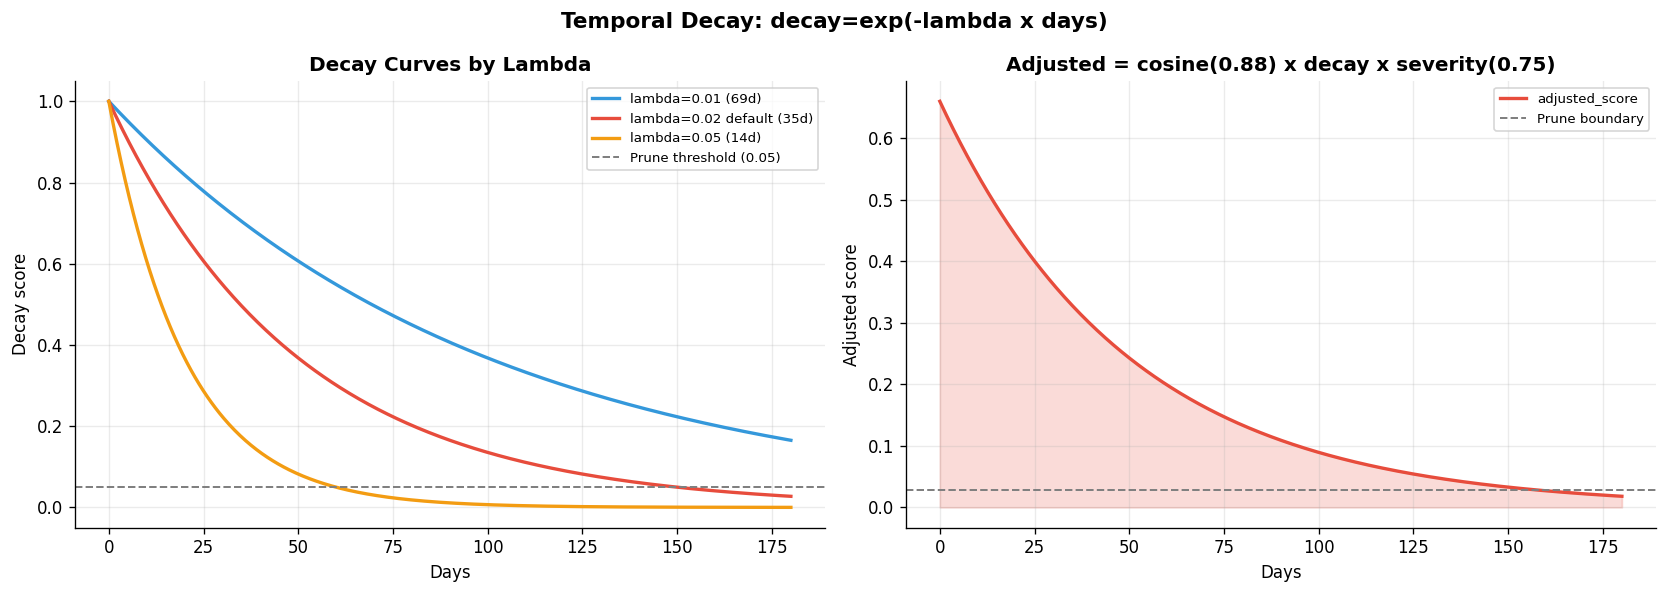

In [5]:
t=np.linspace(0,180,500)
lambdas=[(0.01,'lambda=0.01 (69d)','#3498db'),(0.02,'lambda=0.02 default (35d)','#e74c3c'),(0.05,'lambda=0.05 (14d)','#f39c12')]
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(14,5))
fig.suptitle('Temporal Decay: decay=exp(-lambda x days)',fontsize=13,fontweight='bold')
[ax1.plot(t,np.exp(-lam*t),color=c,lw=2,label=l) for lam,l,c in lambdas]
ax1.axhline(0.05,color='gray',ls='--',lw=1.2,label='Prune threshold (0.05)')
ax1.set_xlabel('Days'); ax1.set_ylabel('Decay score'); ax1.set_title('Decay Curves by Lambda',fontweight='bold')
ax1.legend(fontsize=8); ax1.grid(alpha=0.25)
adjusted=0.88*np.exp(-0.02*t)*0.75
ax2.fill_between(t,adjusted,alpha=0.2,color='#e74c3c')
ax2.plot(t,adjusted,color='#e74c3c',lw=2,label='adjusted_score')
ax2.axhline(0.75*0.05*0.75,color='gray',ls='--',lw=1.2,label='Prune boundary')
ax2.set_xlabel('Days'); ax2.set_ylabel('Adjusted score')
ax2.set_title('Adjusted = cosine(0.88) x decay x severity(0.75)',fontweight='bold')
ax2.legend(fontsize=8); ax2.grid(alpha=0.25)
plt.tight_layout(); plt.savefig('fme_decay_curves.png',dpi=130,bbox_inches='tight'); plt.show()


## 4. Risk Score Distribution & Confidence Gate

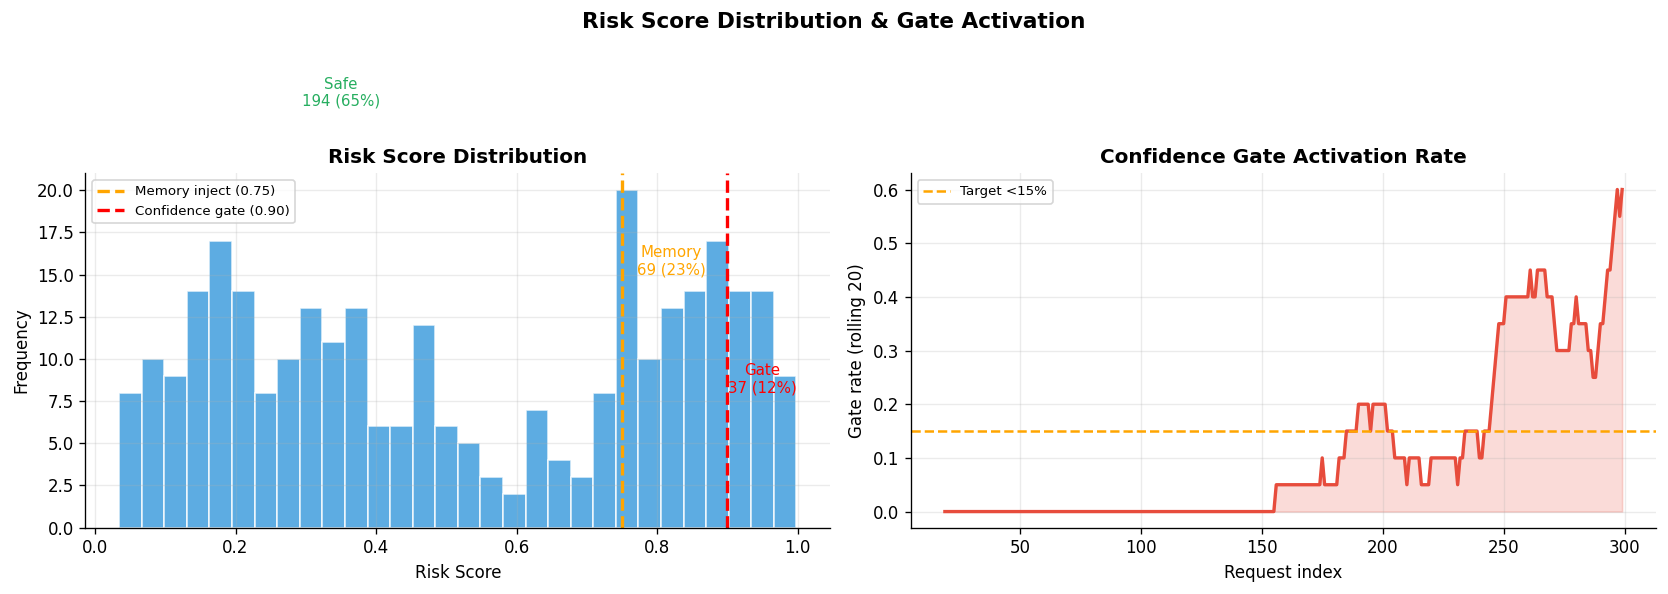

In [6]:
n=300
risk_scores=np.concatenate([np.random.beta(2,5,150),np.random.beta(5,2,80),np.random.uniform(0.7,1.0,70)])
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(14,5))
fig.suptitle('Risk Score Distribution & Gate Activation',fontsize=13,fontweight='bold')
ax1.hist(risk_scores,bins=30,color='#3498db',alpha=0.8,edgecolor='white')
ax1.axvline(0.75,color='orange',ls='--',lw=2,label='Memory inject (0.75)')
ax1.axvline(0.90,color='red',ls='--',lw=2,label='Confidence gate (0.90)')
low=(risk_scores<0.75).sum(); mid=((risk_scores>=0.75)&(risk_scores<0.90)).sum(); high=(risk_scores>=0.90).sum()
ax1.text(0.35,25,f'Safe\n{low} ({low/n:.0%})',ha='center',color='#27ae60',fontsize=9)
ax1.text(0.82,15,f'Memory\n{mid} ({mid/n:.0%})',ha='center',color='orange',fontsize=9)
ax1.text(0.95,8,f'Gate\n{high} ({high/n:.0%})',ha='center',color='red',fontsize=9)
ax1.set_xlabel('Risk Score'); ax1.set_ylabel('Frequency'); ax1.set_title('Risk Score Distribution',fontweight='bold')
ax1.legend(fontsize=8); ax1.grid(alpha=0.25)
gate_act=(risk_scores>=0.90).astype(float)
rolling=pd.Series(gate_act).rolling(20).mean()
ax2.plot(rolling,color='#e74c3c',lw=2); ax2.fill_between(range(len(rolling)),rolling,alpha=0.2,color='#e74c3c')
ax2.axhline(0.15,color='orange',ls='--',lw=1.5,label='Target <15%')
ax2.set_xlabel('Request index'); ax2.set_ylabel('Gate rate (rolling 20)')
ax2.set_title('Confidence Gate Activation Rate',fontweight='bold')
ax2.legend(fontsize=8); ax2.grid(alpha=0.25)
plt.tight_layout(); plt.savefig('fme_risk_distribution.png',dpi=130,bbox_inches='tight'); plt.show()


## 5. Self-Correction Loop Performance

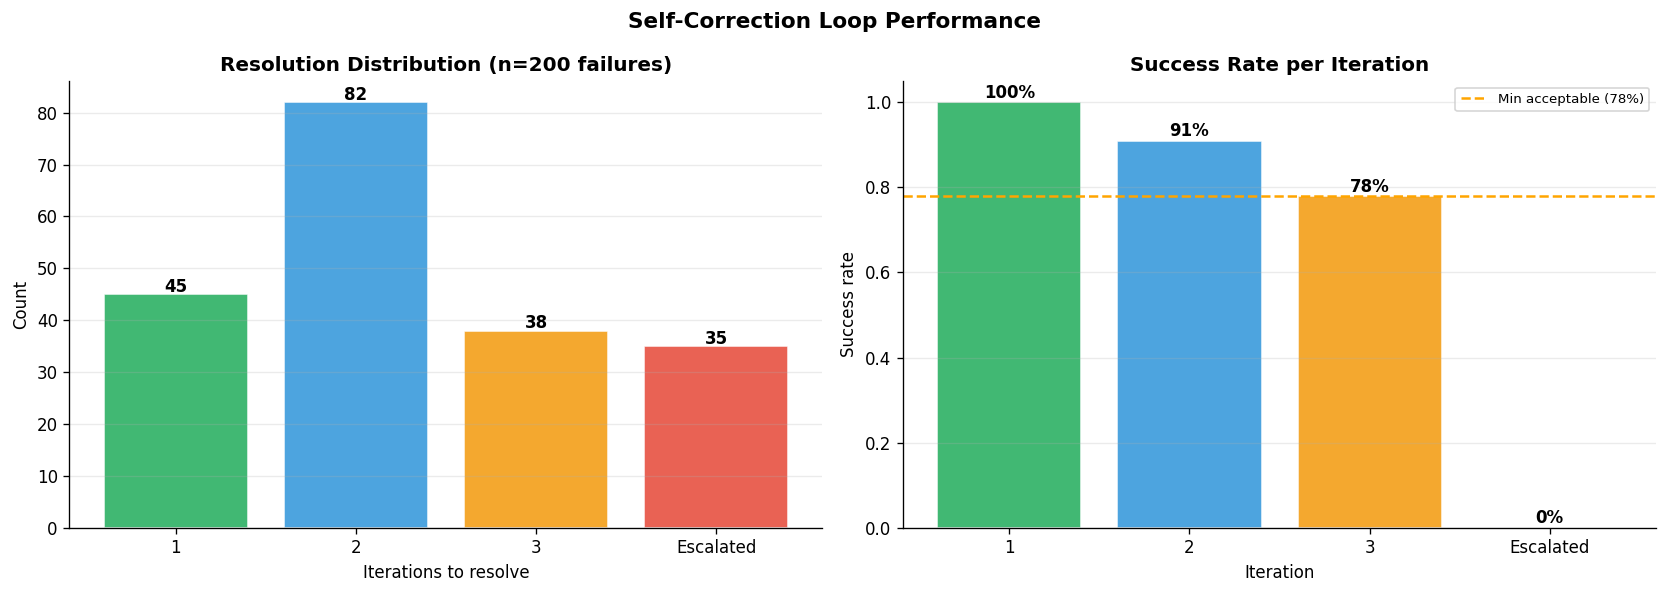

In [7]:
iterations=[1,2,3,'Escalated']; counts_iter=[45,82,38,35]
success_rates=[1.0,0.91,0.78,0.0]
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(14,5))
fig.suptitle('Self-Correction Loop Performance',fontsize=13,fontweight='bold')
colors_iter=['#27ae60','#3498db','#f39c12','#e74c3c']
bars=ax1.bar([str(i) for i in iterations],counts_iter,color=colors_iter,alpha=0.88,edgecolor='white')
[ax1.text(b.get_x()+b.get_width()/2,v+0.5,str(v),ha='center',fontsize=10,fontweight='bold') for b,v in zip(bars,counts_iter)]
ax1.set_xlabel('Iterations to resolve'); ax1.set_ylabel('Count')
ax1.set_title('Resolution Distribution (n=200 failures)',fontweight='bold'); ax1.grid(axis='y',alpha=0.25)
ax2.bar([str(i) for i in iterations],success_rates,color=colors_iter,alpha=0.88,edgecolor='white')
ax2.axhline(0.78,color='orange',ls='--',lw=1.5,label='Min acceptable (78%)')
[ax2.text(i,v+0.01,f'{v:.0%}',ha='center',fontsize=10,fontweight='bold') for i,v in enumerate(success_rates)]
ax2.set_xlabel('Iteration'); ax2.set_ylabel('Success rate')
ax2.set_title('Success Rate per Iteration',fontweight='bold')
ax2.legend(fontsize=8); ax2.grid(axis='y',alpha=0.25)
plt.tight_layout(); plt.savefig('fme_correction_loop.png',dpi=130,bbox_inches='tight'); plt.show()


## 6. Retrieval Precision — Multi-Field vs Baselines

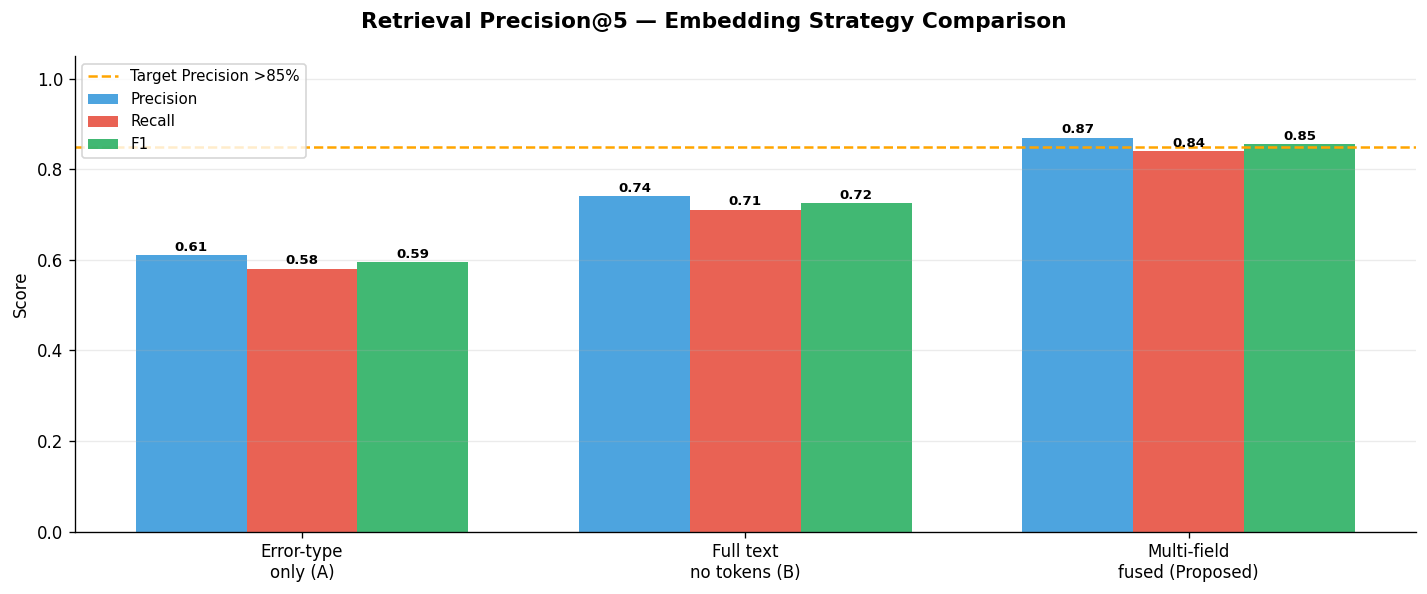

In [8]:
methods=['Error-type\nonly (A)','Full text\nno tokens (B)','Multi-field\nfused (Proposed)']
precision=[0.61,0.74,0.87]; recall=[0.58,0.71,0.84]; f1=[0.595,0.725,0.855]
x=np.arange(3); w=0.25
fig,ax=plt.subplots(figsize=(12,5))
fig.suptitle('Retrieval Precision@5 — Embedding Strategy Comparison',fontsize=13,fontweight='bold')
b1=ax.bar(x-w,precision,w,label='Precision',color='#3498db',alpha=0.88)
b2=ax.bar(x,recall,w,label='Recall',color='#e74c3c',alpha=0.88)
b3=ax.bar(x+w,f1,w,label='F1',color='#27ae60',alpha=0.88)
ax.set_xticks(x); ax.set_xticklabels(methods,fontsize=10)
ax.set_ylim(0,1.05); ax.set_ylabel('Score')
ax.axhline(0.85,color='orange',ls='--',lw=1.5,label='Target Precision >85%')
[[ax.text(b.get_x()+b.get_width()/2,v+0.01,f'{v:.2f}',ha='center',fontsize=8,fontweight='bold') for b,v in zip(bars,vals)] for bars,vals in [(b1,precision),(b2,recall),(b3,f1)]]
ax.legend(fontsize=9); ax.grid(axis='y',alpha=0.25)
plt.tight_layout(); plt.savefig('fme_retrieval_precision.png',dpi=130,bbox_inches='tight'); plt.show()


## 7. Failure Clustering Visualization (UMAP + HDBSCAN)

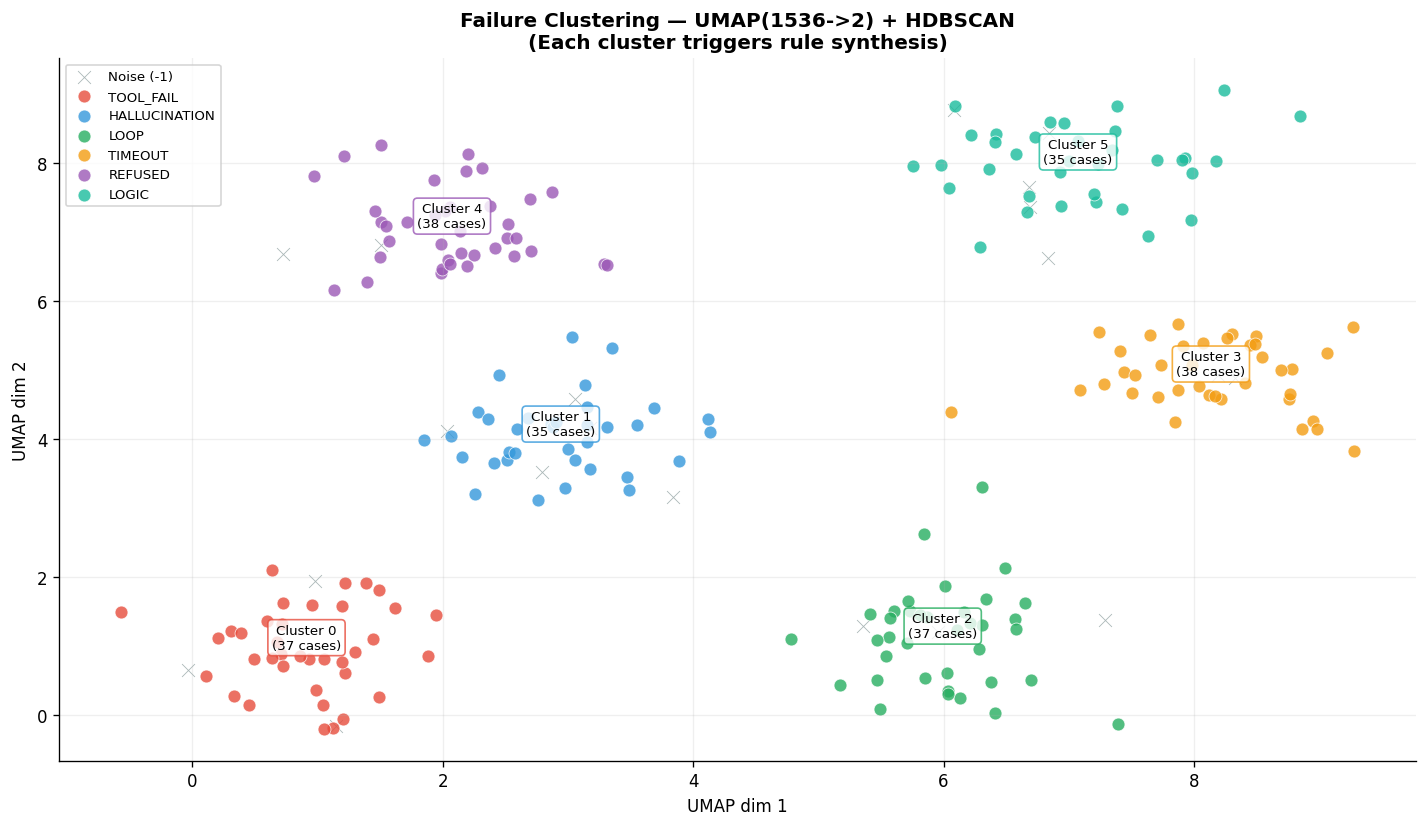

In [9]:
from sklearn.datasets import make_blobs
n_clusters=6; n_per=40
centers=np.array([[1,1],[3,4],[6,1],[8,5],[2,7],[7,8]])
X,y=make_blobs(n_samples=n_per*n_clusters,centers=centers,cluster_std=0.6,random_state=42)
noise_idx=np.random.choice(len(X),20,replace=False)
y[noise_idx]=-1
cluster_colors=['#e74c3c','#3498db','#27ae60','#f39c12','#9b59b6','#1abc9c','#95a5a6']
error_labels=['TOOL_FAIL','HALLUCINATION','LOOP','TIMEOUT','REFUSED','LOGIC','Noise']
fig,ax=plt.subplots(figsize=(12,7))
for cid in range(-1,6):
    mask=y==cid; color=cluster_colors[cid] if cid>=0 else '#95a5a6'
    label=error_labels[cid] if cid>=0 else 'Noise (-1)'
    marker='x' if cid==-1 else 'o'
    ax.scatter(X[mask,0],X[mask,1],c=color,label=label,alpha=0.8,s=60,marker=marker,edgecolors='white',linewidth=0.5)
    if cid>=0:
        cx,cy=X[mask,0].mean(),X[mask,1].mean()
        ax.annotate(f'Cluster {cid}\n({mask.sum()} cases)',xy=(cx,cy),ha='center',fontsize=8,
                    bbox=dict(boxstyle='round,pad=0.3',facecolor='white',alpha=0.8,edgecolor=color))
ax.set_title('Failure Clustering — UMAP(1536->2) + HDBSCAN\n(Each cluster triggers rule synthesis)',fontweight='bold',fontsize=12)
ax.legend(fontsize=8,loc='upper left'); ax.grid(alpha=0.2)
ax.set_xlabel('UMAP dim 1'); ax.set_ylabel('UMAP dim 2')
plt.tight_layout(); plt.savefig('fme_clustering.png',dpi=130,bbox_inches='tight'); plt.show()


## 8. Evaluation Metrics Dashboard (FRR, MRS, Precision@5, ECE)

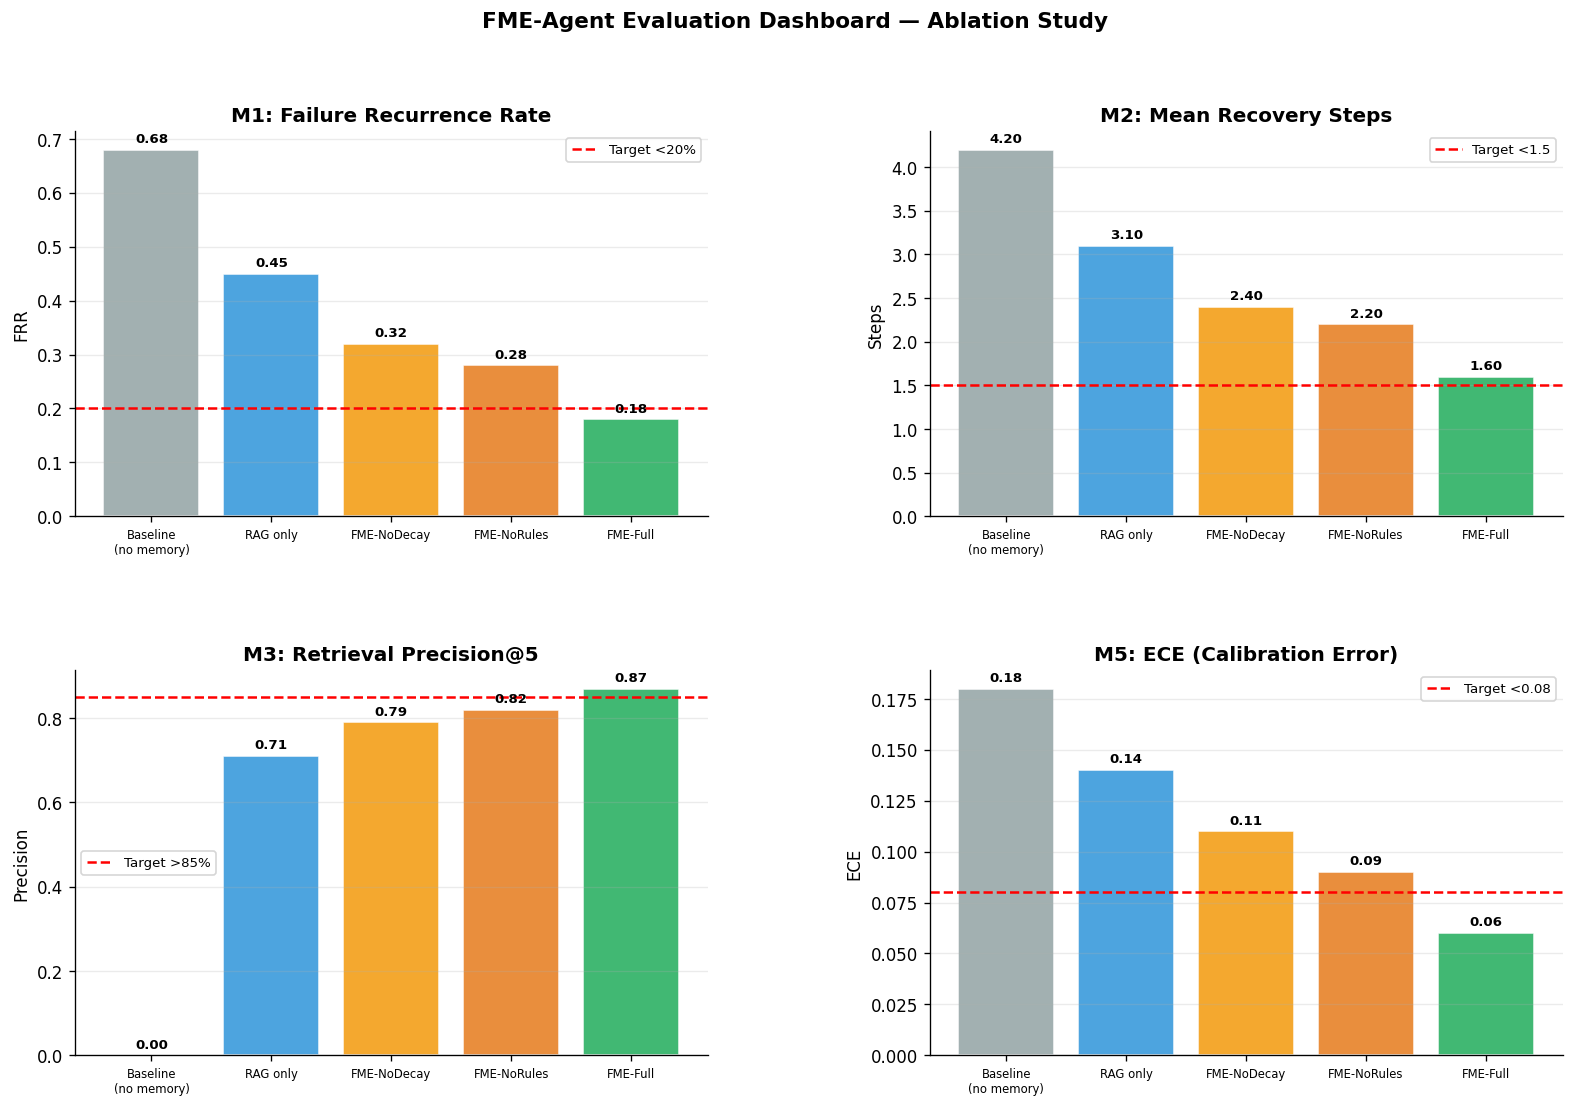

In [10]:
systems=['Baseline\n(no memory)','RAG only','FME-NoDecay','FME-NoRules','FME-Full']
frr=[0.68,0.45,0.32,0.28,0.18]
mrs=[4.2,3.1,2.4,2.2,1.6]
prec5=[0.0,0.71,0.79,0.82,0.87]
ece=[0.18,0.14,0.11,0.09,0.06]
colors_sys=['#95a5a6','#3498db','#f39c12','#e67e22','#27ae60']
fig=plt.figure(figsize=(16,10))
gs=gridspec.GridSpec(2,2,figure=fig,hspace=0.4,wspace=0.35)
fig.suptitle('FME-Agent Evaluation Dashboard — Ablation Study',fontsize=13,fontweight='bold')
for ax_spec,metric,title,ylabel,target,target_label,lower_better in [
    (gs[0,0],frr,'M1: Failure Recurrence Rate','FRR',0.20,'Target <20%',True),
    (gs[0,1],mrs,'M2: Mean Recovery Steps','Steps',1.5,'Target <1.5',True),
    (gs[1,0],prec5,'M3: Retrieval Precision@5','Precision',0.85,'Target >85%',False),
    (gs[1,1],ece,'M5: ECE (Calibration Error)','ECE',0.08,'Target <0.08',True),
]:
    ax=fig.add_subplot(ax_spec)
    bars=ax.bar(systems,metric,color=colors_sys,alpha=0.88,edgecolor='white')
    ax.axhline(target,color='red',ls='--',lw=1.5,label=target_label)
    [ax.text(b.get_x()+b.get_width()/2,v+(max(metric)*0.02),f'{v:.2f}',ha='center',fontsize=8,fontweight='bold') for b,v in zip(bars,metric)]
    ax.set_title(title,fontweight='bold'); ax.set_ylabel(ylabel)
    ax.legend(fontsize=8); ax.grid(axis='y',alpha=0.25)
    ax.tick_params(axis='x',labelsize=7)
plt.savefig('fme_evaluation_dashboard.png',dpi=130,bbox_inches='tight'); plt.show()


## 9. Pre-Measure: Failure Forecasting P(failure)

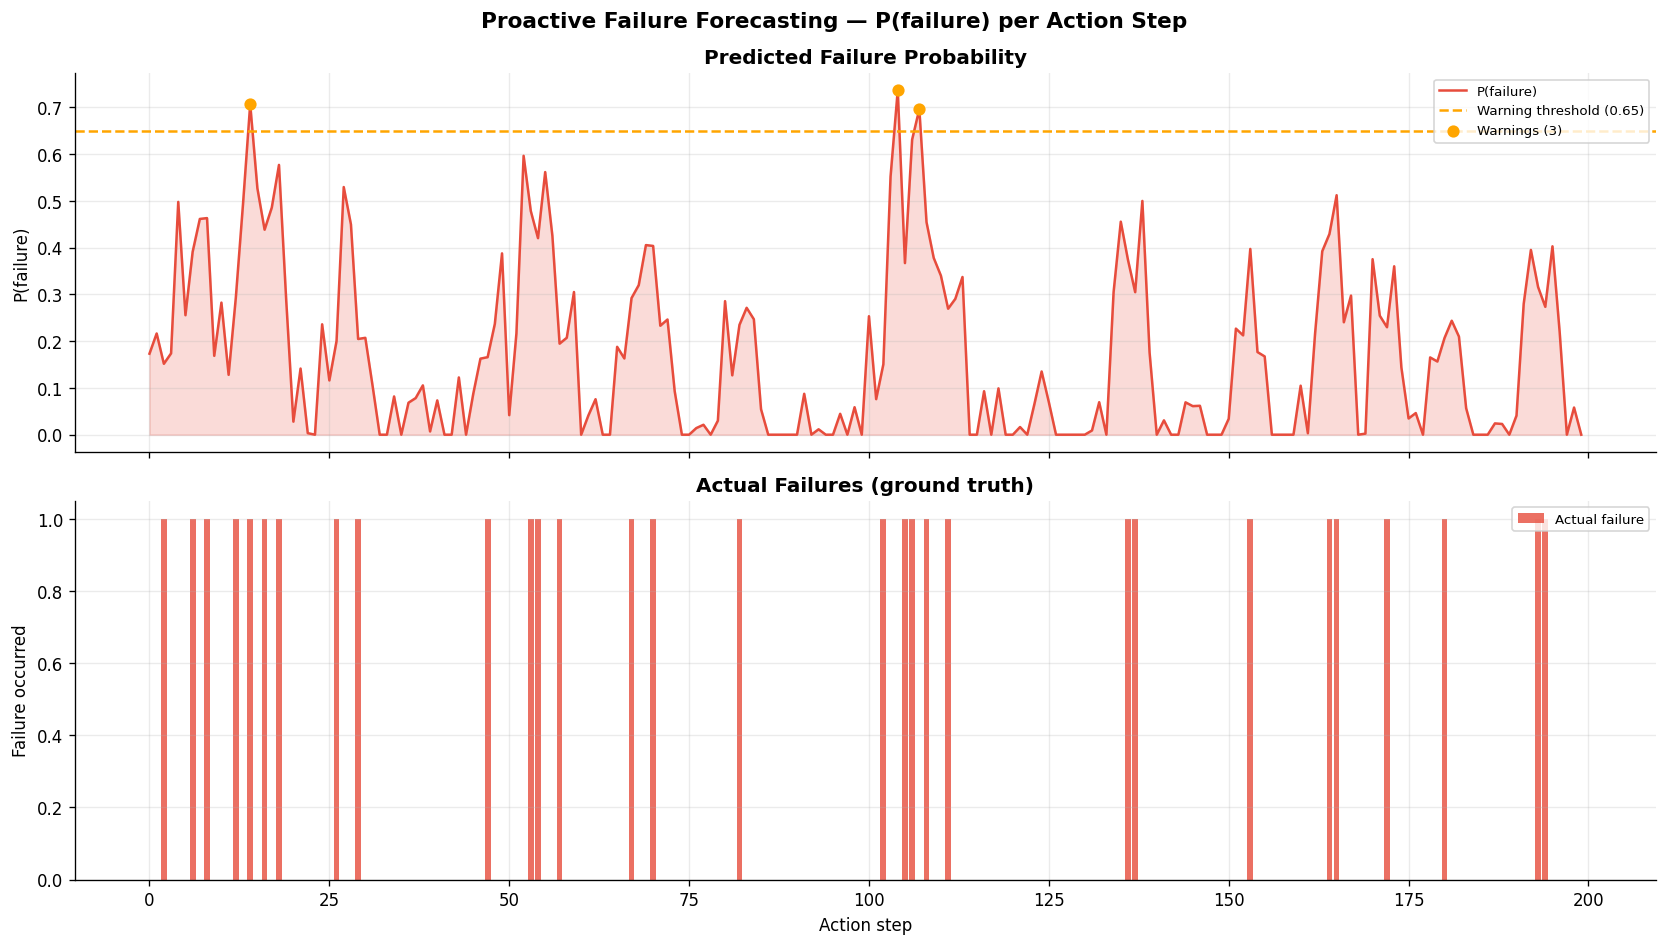

Forecaster AUC-ROC: 0.831


In [11]:
n_steps=200
t_steps=np.arange(n_steps)
true_failure=np.zeros(n_steps); true_failure[np.random.choice(n_steps,30,replace=False)]=1
p_failure=np.clip(np.convolve(true_failure,np.ones(5)/5,mode='same')+np.random.normal(0,0.08,n_steps),0,1)
fig,(ax1,ax2)=plt.subplots(2,1,figsize=(14,8),sharex=True)
fig.suptitle('Proactive Failure Forecasting — P(failure) per Action Step',fontsize=13,fontweight='bold')
ax1.plot(t_steps,p_failure,color='#e74c3c',lw=1.5,label='P(failure)')
ax1.fill_between(t_steps,p_failure,alpha=0.2,color='#e74c3c')
ax1.axhline(0.65,color='orange',ls='--',lw=1.5,label='Warning threshold (0.65)')
warn_idx=np.where(p_failure>=0.65)[0]
ax1.scatter(warn_idx,p_failure[warn_idx],color='orange',s=40,zorder=5,label=f'Warnings ({len(warn_idx)})')
ax1.set_ylabel('P(failure)'); ax1.set_title('Predicted Failure Probability',fontweight='bold')
ax1.legend(fontsize=8); ax1.grid(alpha=0.25)
ax2.bar(t_steps,true_failure,color='#e74c3c',alpha=0.8,label='Actual failure')
ax2.set_xlabel('Action step'); ax2.set_ylabel('Failure occurred')
ax2.set_title('Actual Failures (ground truth)',fontweight='bold')
ax2.legend(fontsize=8); ax2.grid(alpha=0.25)
plt.tight_layout(); plt.savefig('fme_forecasting.png',dpi=130,bbox_inches='tight'); plt.show()
from sklearn.metrics import roc_auc_score
auc=roc_auc_score(true_failure,p_failure)
print(f'Forecaster AUC-ROC: {auc:.3f}')


## 10. Ablation Study — FME Component Contribution

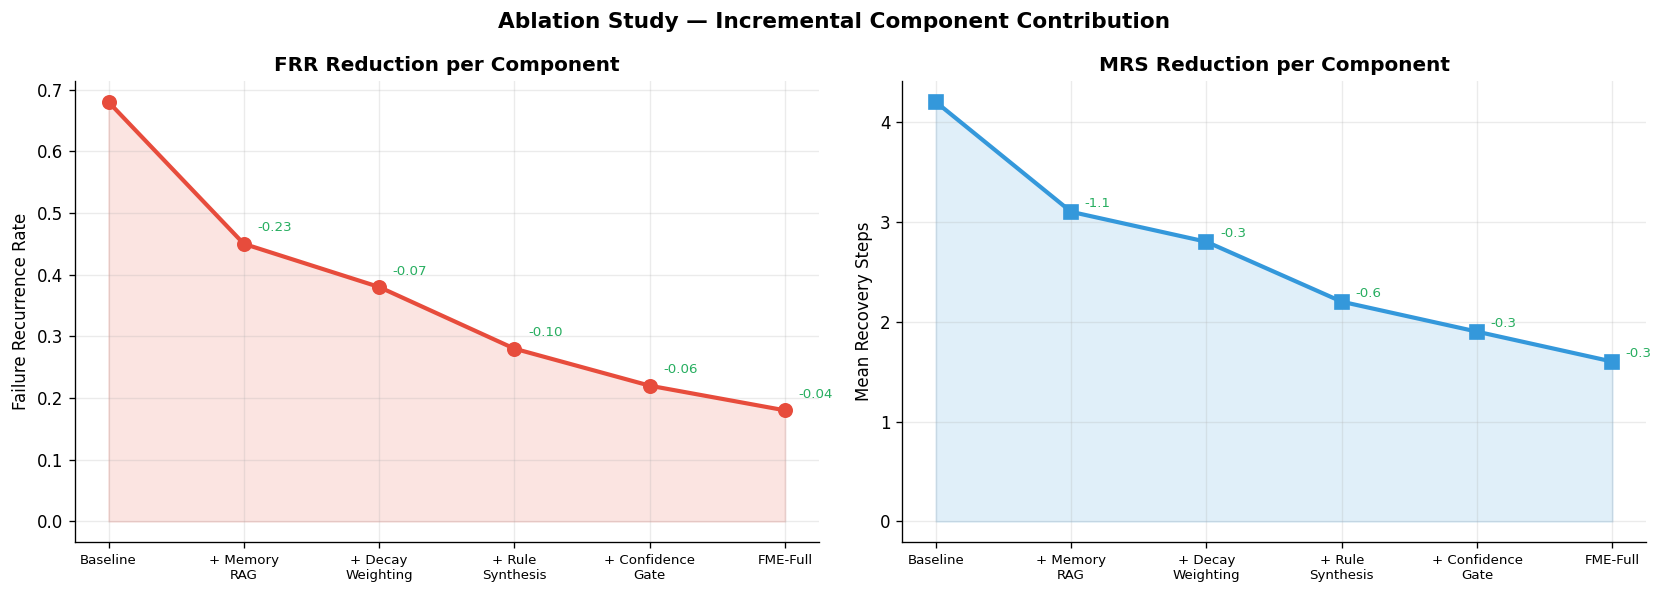

In [12]:
components=['Baseline','+ Memory\nRAG','+ Decay\nWeighting','+ Rule\nSynthesis','+ Confidence\nGate','FME-Full']
frr_ablation=[0.68,0.45,0.38,0.28,0.22,0.18]
mrs_ablation=[4.2,3.1,2.8,2.2,1.9,1.6]
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(14,5))
fig.suptitle('Ablation Study — Incremental Component Contribution',fontsize=13,fontweight='bold')
x=np.arange(len(components))
ax1.plot(x,frr_ablation,'o-',color='#e74c3c',lw=2.5,markersize=8,label='FRR')
ax1.fill_between(x,frr_ablation,alpha=0.15,color='#e74c3c')
for i,(xi,v) in enumerate(zip(x,frr_ablation)):
    if i>0: ax1.annotate(f'-{frr_ablation[i-1]-v:.2f}',xy=(xi,v),xytext=(xi+0.1,v+0.02),fontsize=8,color='#27ae60')
ax1.set_xticks(x); ax1.set_xticklabels(components,fontsize=8)
ax1.set_ylabel('Failure Recurrence Rate'); ax1.set_title('FRR Reduction per Component',fontweight='bold')
ax1.grid(alpha=0.25)
ax2.plot(x,mrs_ablation,'s-',color='#3498db',lw=2.5,markersize=8,label='MRS')
ax2.fill_between(x,mrs_ablation,alpha=0.15,color='#3498db')
for i,(xi,v) in enumerate(zip(x,mrs_ablation)):
    if i>0: ax2.annotate(f'-{mrs_ablation[i-1]-v:.1f}',xy=(xi,v),xytext=(xi+0.1,v+0.05),fontsize=8,color='#27ae60')
ax2.set_xticks(x); ax2.set_xticklabels(components,fontsize=8)
ax2.set_ylabel('Mean Recovery Steps'); ax2.set_title('MRS Reduction per Component',fontweight='bold')
ax2.grid(alpha=0.25)
plt.tight_layout(); plt.savefig('fme_ablation.png',dpi=130,bbox_inches='tight'); plt.show()


## 11. Summary — All Charts Saved

In [13]:
charts=['fme_failure_distribution.png','fme_root_cause_heatmap.png','fme_decay_curves.png',
        'fme_risk_distribution.png','fme_correction_loop.png','fme_retrieval_precision.png',
        'fme_clustering.png','fme_evaluation_dashboard.png','fme_forecasting.png','fme_ablation.png']
print('Charts generated:')
for c in charts:
    exists=os.path.exists(c)
    print(f'  {"OK" if exists else "MISSING"}  {c}')


Charts generated:
  OK  fme_failure_distribution.png
  OK  fme_root_cause_heatmap.png
  OK  fme_decay_curves.png
  OK  fme_risk_distribution.png
  OK  fme_correction_loop.png
  OK  fme_retrieval_precision.png
  OK  fme_clustering.png
  OK  fme_evaluation_dashboard.png
  OK  fme_forecasting.png
  OK  fme_ablation.png
